# ECE1508: Applied Deep Learning
# Assignment 1

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

Try an example

In [2]:
np.ones(3)

array([1., 1., 1.])

## Programming Question 1

In [3]:
class LinearMachine():
    def __init__(self):
        # Define weights as attribute
        # Set the initial values randomly
        self._weights = np.random.randn(2)

        pass

    def data_synthesizer(self, dataset_size, velocity_mean, velocity_var,
                         height_mean, height_var):

        # Draw random velocity and height
        # Let the array size to be <dataset_size>
        # Don't forget to make them positive using np.abs()

        v_sample = np.abs(np.random.normal(velocity_mean,  velocity_var, dataset_size))
        h_sample = np.abs(np.random.normal(height_mean, height_var, dataset_size))

        # Compute distance d via Newton's law
        d_sample = 0.45 * v_sample * np.sqrt(h_sample)

        # Make the dataset
        dataset = dataset = np.column_stack((v_sample, h_sample, d_sample))
        return dataset


    def train_GD(self, dataset, lr, delta = float("inf"), max_iterations = 1e12):

        # We can reset the weights to some initial random values
        self._weights = np.random.randn(2)


        # read data-points and labels
        x_mat = dataset[:, :2]  # velocity, height: input
        d_mat = dataset[:, 2]   # distance: label

        # Count number of iterations to stop after max iterations
        counter = 0

        # Initiate risk
        risk = 0

        while delta > 0 and counter < max_iterations:

            # Compute Gradient
            err = np.dot(x_mat,self._weights) - d_mat
            grad = np.dot(x_mat.T, err) / len(d_mat)

            # Save risk at current weights
            old_risk = risk

            # Update weights using GD with learning rate lr
            self._weights -= lr * grad

            # Compute new risk
            pred_new = np.dot(x_mat, self._weights)
            risk = np.mean((pred_new - d_mat) ** 2)

            # Update stopping criteria
            delta = np.abs(risk - old_risk)
            counter += 1

        # Print out if the code stops due to max iterations, i.e., GD did not converge
        if counter == max_iterations:
            print(f"GD dos not converge: train_GD hit max iterations = {max_iterations}!")

        return risk


    def train(self, dataset):

          x_mat = dataset[:, :2]  # velocity, height: input
          d_mat = dataset[:, 2]   # distance: label
          # Find the minimizer
          x_transpose = np.transpose(x_mat)
          self._weights = np.linalg.inv(np.dot(x_transpose, x_mat)).dot(np.dot(x_transpose, d_mat))

          # Compute minimum risk
          pred = np.dot(x_mat, self._weights)
          risk_opt = np.mean((pred - d_mat) ** 2)

          return risk_opt

    def test(self, J, velocity_mean, velocity_var, height_mean, height_var):

          # Generate an independent dataset for test
          dataset = self.data_synthesizer(J, velocity_mean, velocity_var, height_mean, height_var)


          # Split dataset into input features and labels
          x_mat = dataset[:, :2]  # velocity, height： input
          d_mat = dataset[:, 2]   # distance, label

          # Compute the risk via the trained weights
          y_pred = np.dot(x_mat, self._weights)

          # Compute test risk
          risk_test = np.mean((y_pred - d_mat) ** 2)

          return risk_test





### Gradient Descent vs Optimal Training

/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
<ipython-input-3-7d155ae3786a>:60: RuntimeWarning: invalid value encountered in scalar subtract
  delta = np.abs(risk - old_risk)


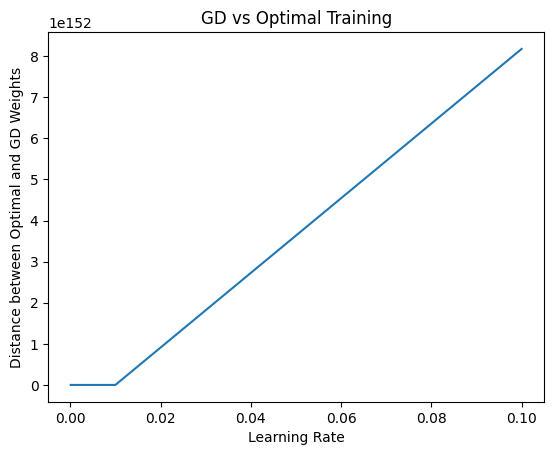

In [4]:
def Optimality_Gap(lr_list):
    myModel = LinearMachine()
    dataset = myModel.data_synthesizer(100, 1, 5, 3, 3)

    # Initiate optimality gap vector
    Opt_gap = []

    # Find optimal weights
    myModel.train(dataset)
    weights_optimal = myModel._weights

    # Find GD trained weights
    for lr in lr_list:
        # ============ COMPLETE HERE ================
        myModel.train_GD(dataset, lr)
        weights_GD = myModel._weights
        # ============================================

        # Append the optimality gap
        Opt_gap.append(np.linalg.norm(weights_optimal-weights_GD))


    # Plot
    plt.figure()
    plt.plot(lr_list, Opt_gap)
    plt.title('GD vs Optimal Training')
    plt.xlabel('Learning Rate')
    plt.ylabel('Distance between Optimal and GD Weights')

    plt.show()


# Execute your implementation
Optimality_Gap([0.1, 0.01, 0.001, 0.0001])

### Test Loop

Text(0, 0.5, 'Test Risk')

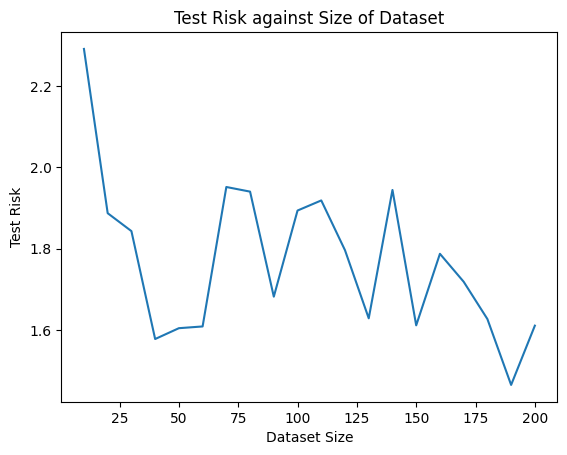

In [5]:
def eval_model(T, I, J, velocity_mean, velocity_var, height_mean, height_var):
  myModel = LinearMachine()
  lr = 0.001

  # Initiate the risk
  emp_risk = 0

  # Loop over t
  for t in range(T):
      # Generate training and test datasets
      train_dataset = myModel.data_synthesizer(I, velocity_mean, velocity_var, height_mean, height_var)

      # Train the model using the training dataset
      myModel.train(train_dataset)

      # Accumulate the risk
      emp_risk += myModel.test(J, velocity_mean, velocity_var, height_mean, height_var)


  # average rist over datasets
  emp_risk = emp_risk / T

  return emp_risk


# Make list for plot
emp_risk_list = []
T, J = 100, 10

# loop over I
I_list = [10*i for i in range(1,21)]
for I in I_list:
  emp_risk_list.append(eval_model(T, I, J, 1, 5, 3, 3))


# Plot
plt.figure()
plt.plot(I_list, emp_risk_list)
plt.title('Test Risk against Size of Dataset')
plt.xlabel('Dataset Size')
plt.ylabel('Test Risk')


## Programming Question 2

### Perceptron Machine

In [6]:
class PerceptronMachine():
    def __init__(self):
        # define weights as attribute and initiate randomly
        self._dimensions = 9
        self.weights = np.random.randn(self._dimensions)  # Random weights for 9 inputs
        self.bias = np.random.randn()  # Initialize bias randomly

    def forward(self, datapoint):
        # Affine function
        affine = np.dot(self.weights, datapoint) + self.bias

        # Activate by step function
        return 1 if affine > 0 else 0

    def train(self, dataset, lr):
        # initiate weights again randomly as we start with training
        self.weights = np.random.randn(self._dimensions)
        self.bias = np.random.randn()

        # initiate error_flag with 1 to get to the while loop
        error_flag = 1

        while error_flag > 0:
            # We initially have no error
            error_flag = 0
            for data in dataset:
                # Read data
                x = data[0]
                label = data[1]

                # Pass it forward
                y = self.forward(x)

                # Implement inner loop
                if y != label:
                    # Find sign(z)
                    z_sign = label - y


                    # Update
                    self.weights += lr * z_sign * x
                    self.bias += lr * z_sign

                    # Since we had error, we set the flag 1 again
                    error_flag = 1


### X Pattern

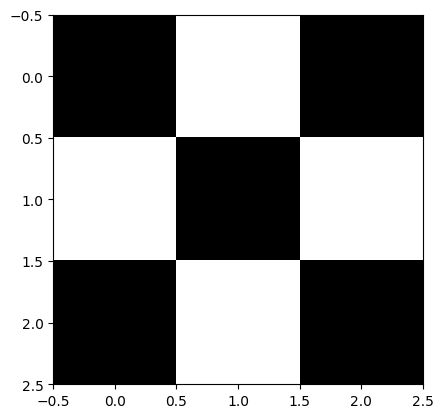

In [7]:
# Generating the X Pattern
# Run this code to see X pattern

x = 256* np.ones([3,3],dtype = int)

for i in range(3):
    x[i,i] = 0
    x[i,2-i] = 0

plt.imshow(x,cmap='gray')

### Generate Dataset and Train

In [8]:
# Generate the Dataset
# Initiate empty dataset
dataset = []
image_list = []

# We have 2^9=512 possibilities: loop over them
for i in range(512):
    # generate 9-dimensional vector
    binary_vector = [(i >> bit) & 1 for bit in range(8, -1, -1)]
    image = 256 * np.array(binary_vector)

    # label the vector
    label = 0
    if np.array_equal(image, np.array([0, 256, 0, 256, 0, 256, 0, 256, 0])):
          # X pattern label
          label  = 1

    image_list.append(image)
    dataset.append((image, label))


# Instantiate a perceptron and train it
myModel = PerceptronMachine()
myModel.train(dataset, 0.001)


### Test Trained Model

In [9]:
# Initiate the test set
testset = []

# Add the X pattern
testset.append([0, 256, 0, 256, 0, 256, 0, 256, 0])

# Choose some data samples
for i in range(10):
    rand_idx = int(np.random.rand() * 512) % 512
    while rand_idx == 170:
        rand_idx = int(np.random.rand() * 512) % 512
    testset.append(dataset[rand_idx][0])


# Test the set: only the first one should return 1
for test in testset:
    print(f"Is it X patter? Answer: {myModel.forward(test)}")


Is it X patter? Answer: 1
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
Is it X patter? Answer: 0
